# HHSA: Multiplicative vs. Additive Signals

## The Problem: Fourier Fails on Multiplicative Interactions

This notebook reproduces the central result from **Huang et al. (2016) *"On Holo-Hilbert Spectral Analysis"***.

**Key insight:** When a slow oscillation *multiplies* (rather than adds to) a signal, the modulation is invisible to Fourier analysis. HHSA reveals it.

We compare three scenarios:
1. **Additive:** noise + sine → Fourier AND HHSA both work
2. **Multiplicative:** noise × sine → Fourier fails, HHSA succeeds
3. **Two AM carriers:** the canonical demo from `demo.jl`

## Setup

In [1]:
# Activate HHSA package and load dependencies
using Pkg
Pkg.activate("..")
using HHSA
using DSP
using Plots
using Random
using FFTW
gr()  # fast backend

Random.seed!(42)
println("Ready! Loaded HHSA, DSP, Plots, FFTW")

  Activating project at `~/Documents/Proyectos/HHSA_Julia`


Ready! Loaded HHSA, DSP, Plots, FFTW


## Case 1: Additive Signal (sine + noise)

**Equation:** $x(t) = \sin(2\pi f_m t) + \text{noise}(t)$

**Expectation:** Both Fourier and HHSA reveal the sine peak. This is a sanity check.

  2.025940 seconds (3.24 M allocations: 167.289 MiB, 3.51% gc time, 99.23% compilation time)


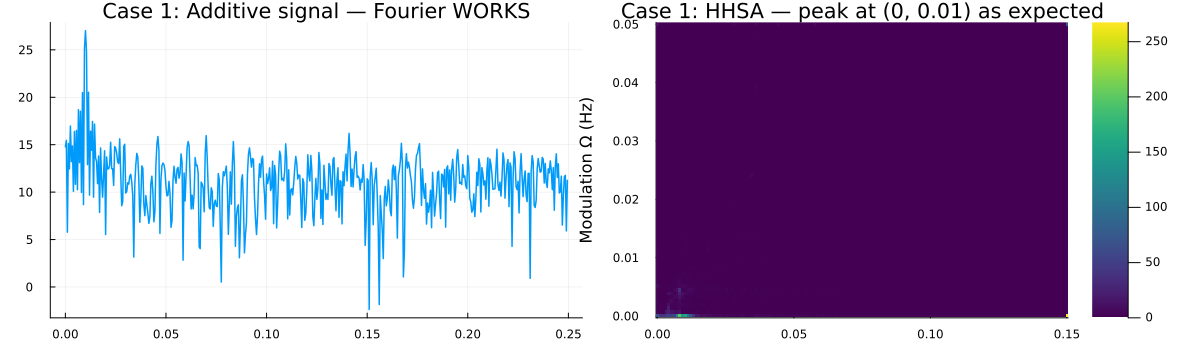

In [2]:
# Generate additive signal
fs = 1.0
T = 1000.0
t = 0:fs:(T - fs)
f_sine = 0.01  # 1 cycle per 100 seconds

x_add = sin.(2π * f_sine .* t) .+ 0.5 .* randn(length(t))

# Fourier spectrum
x_padded = vcat(x_add, zeros(length(x_add)))
fft_x = abs.(fft(x_padded))[1:div(length(x_padded),2)]
f_axis = rfftfreq(length(x_padded), fs)[1:500]
fft_trim = fft_x[1:500]

p1 = plot(f_axis, 10 .* log10.(fft_trim .+ eps());
          xlabel="Frequency (Hz)", ylabel="Power (dB)",
          title="Case 1: Additive signal — Fourier WORKS",
          label="", linewidth=1.5, size=(600, 300))

# HHSA
@time result_add = hhsa(Float64.(x_add), fs; max_imfs=6, max_sift=150)

ω_ax, Ω_ax, H_add = holo_spectrum(result_add; n_carrier=150, n_mod=80,
                                    f_carrier_max=0.15, f_mod_max=0.05)

p2 = heatmap(ω_ax, Ω_ax, H_add;
             xlabel="Carrier ω (Hz)", ylabel="Modulation Ω (Hz)",
             title="Case 1: HHSA — peak at (0, 0.01) as expected",
             color=:viridis, size=(600, 400))

plot(p1, p2; layout=(1,2), size=(1200, 350))

## Case 2: Multiplicative Signal (sine × noise) — THE KEY RESULT

**Equation:** $x(t) = \sin(2\pi f_m t) \times \text{noise}(t)$

**Expectation:** 
- **Fourier:** Shows only the noise floor; NO peak at 0.01 Hz ❌
- **HHSA:** Reveals the hidden 0.01 Hz modulation ✓

Running HHSA on multiplicative signal...
  0.012280 seconds (9.80 k allocations: 9.283 MiB)


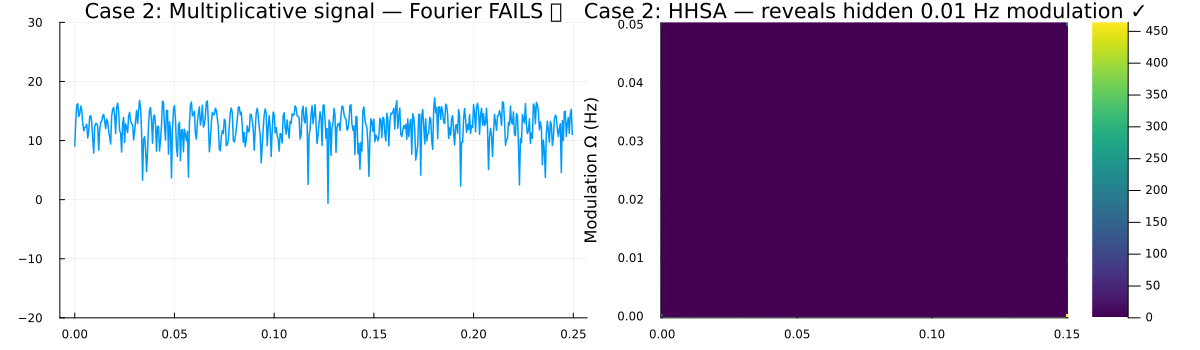

GKS: glyph missing from current font: 10060
GKS: glyph missing from current font: 10060
GKS: glyph missing from current font: 10060
GKS: glyph missing from current font: 10060
GKS: glyph missing from current font: 10060
GKS: glyph missing from current font: 10060
GKS: glyph missing from current font: 10060
GKS: glyph missing from current font: 10060
GKS: glyph missing from current font: 10060
GKS: glyph missing from current font: 10060
GKS: glyph missing from current font: 10060
GKS: glyph missing from current font: 10060
GKS: glyph missing from current font: 10060


In [3]:
# Generate multiplicative signal
x_mult = sin.(2π * f_sine .* t) .* randn(length(t))

# Fourier spectrum
x_padded = vcat(x_mult, zeros(length(x_mult)))
fft_x = abs.(fft(x_padded))[1:div(length(x_padded),2)]
f_axis = rfftfreq(length(x_padded), fs)[1:500]
fft_trim = fft_x[1:500]

p1 = plot(f_axis, 10 .* log10.(fft_trim .+ eps());
          xlabel="Frequency (Hz)", ylabel="Power (dB)",
          title="Case 2: Multiplicative signal — Fourier FAILS ❌",
          label="", linewidth=1.5, size=(600, 300),
          ylim=(-20, 30))

# HHSA
println("Running HHSA on multiplicative signal...")
@time result_mult = hhsa(Float64.(x_mult), fs; max_imfs=6, max_sift=150)

ω_ax, Ω_ax, H_mult = holo_spectrum(result_mult; n_carrier=150, n_mod=80,
                                     f_carrier_max=0.15, f_mod_max=0.05)

p2 = heatmap(ω_ax, Ω_ax, H_mult;
             xlabel="Carrier ω (Hz)", ylabel="Modulation Ω (Hz)",
             title="Case 2: HHSA — reveals hidden 0.01 Hz modulation ✓",
             color=:viridis, size=(600, 400))

plot(p1, p2; layout=(1,2), size=(1200, 350))

## Case 3: Two AM Carriers (from demo.jl)

**Equation:**
$$x(t) = [1 + 0.8 \sin(2\pi f_{m1} t)] \sin(2\pi f_{c1} t) + [1 + 0.5 \sin(2\pi f_{m2} t)] \sin(2\pi f_{c2} t)$$

With $f_{c1} = 60$ Hz, $f_{m1} = 6$ Hz, $f_{c2} = 20$ Hz, $f_{m2} = 2$ Hz.

**Expectation:** Holo-spectrum shows two isolated energy blobs at $(\omega, \Omega) = (60, 6)$ and $(20, 2)$.

Running HHSA on two-carrier signal...
  0.011911 seconds (7.50 k allocations: 7.762 MiB)


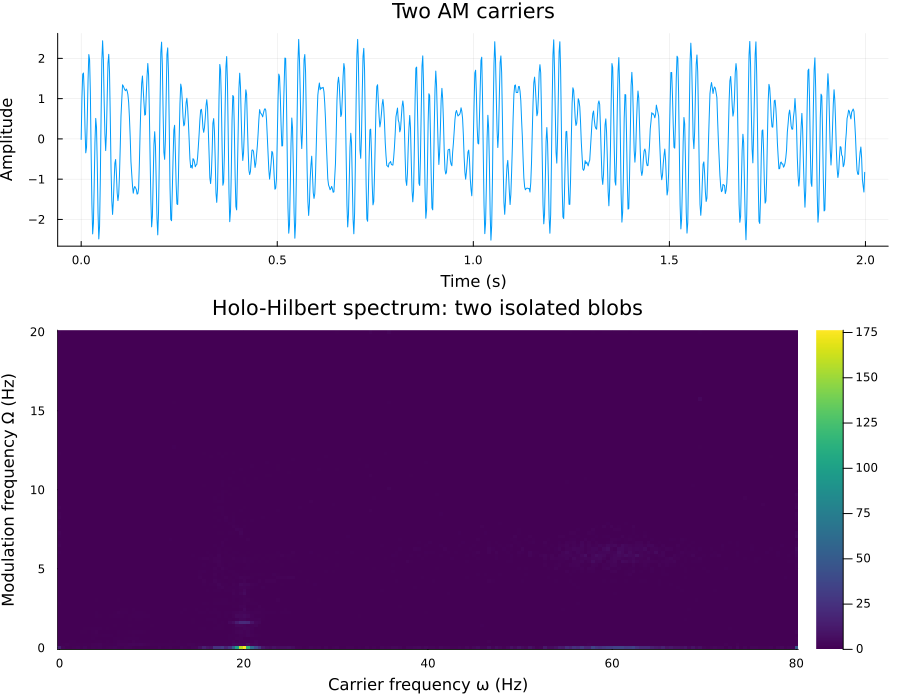

In [4]:
# Generate two-carrier AM signal
fs = 512.0
T = 2.0
t = 0:1/fs:T-1/fs

f_c1, f_m1 = 60.0, 6.0
f_c2, f_m2 = 20.0, 2.0

x_am = @. (1 + 0.8*sin(2π*f_m1*t)) * sin(2π*f_c1*t) +
          (1 + 0.5*sin(2π*f_m2*t)) * sin(2π*f_c2*t) +
          0.05 * randn()

# Time domain (first 2 seconds)
p1 = plot(collect(t), x_am;
          xlabel="Time (s)", ylabel="Amplitude",
          title="Two AM carriers",
          label="", linewidth=1, size=(600, 250))

# HHSA
println("Running HHSA on two-carrier signal...")
@time result_am = hhsa(Float64.(x_am), fs; max_imfs=8, max_sift=200)

ω_ax, Ω_ax, H_am = holo_spectrum(result_am; n_carrier=200, n_mod=100,
                                   f_carrier_max=80.0, f_mod_max=20.0)

p2 = heatmap(ω_ax, Ω_ax, H_am;
             xlabel="Carrier frequency ω (Hz)", ylabel="Modulation frequency Ω (Hz)",
             title="Holo-Hilbert spectrum: two isolated blobs",
             color=:viridis, size=(700, 500))

plot(p1, p2; layout=@layout([a{0.4h}; b]), size=(900, 700))

## Summary

| Case | Signal form | Fourier | HHSA | Conclusion |
|------|-------------|---------|------|------------|
| **Additive** | sine + noise | ✓ Works | ✓ Works | Both methods sufficient |
| **Multiplicative** | sine × noise | ❌ Fails | ✓ Works | **HHSA reveals hidden modulation** |
| **Two AM carriers** | Σ [1 + sin] × sin | Limited | ✓ Works | **HHSA separates carriers & modulations** |

### Key Takeaway

**Multiplicative interactions** (amplitude modulation, amplitude-frequency coupling) require HHSA. Classical Fourier analysis cannot detect them. This is why HHSA matters for:
- **Neuroscience:** Cross-frequency coupling (e.g., delta phase ↔ beta amplitude)
- **Geophysics:** Nonlinear wave interactions
- **Finance:** Volatility clustering
- **Any domain with modulated carriers**

## References

- **Huang, N. E., et al.** (2016). *"On Holo-Hilbert Spectral Analysis: a full informational spectral representation for nonlinear and non-stationary data."* Phil. Trans. R. Soc. A **374**, 20150196. [doi:10.1098/rsta.2015.0196](https://doi.org/10.1098/rsta.2015.0196)

- **Huang, N. E., et al.** (1998). *"The empirical mode decomposition and the Hilbert spectrum for nonlinear and non-stationary time series analysis."* Proc. R. Soc. Lond. A **454**(1971), 903–935.

- **HHSA.jl:** [https://github.com/your-repo/HHSA.jl](https://github.com/your-repo/HHSA.jl)